In [1]:
# Full notebook time profiling
from datetime import datetime
start_dt = datetime.now()

In [2]:
# Importing needed code

from pathlib import Path
from typing import Callable, Literal
from datetime import datetime, time, date, timedelta
from dataclasses import dataclass

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statistics as stat

from data_processing.processing.figure_of_merit import ( 
    FOM, 
    gaussian, 
    bimodal
)

from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

Matplotlib created a temporary config/cache directory at /tmp/pbs.4546493.pbsha.ib.sockeye/matplotlib-x9wg1cfi because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


# Load Data

In [3]:
# Defining variables for important ARC folders

alloc_code = 'st-cberling-1'
project_folder = Path('/arc/project') / alloc_code
scratch_folder = Path('scratch') / alloc_code
input_data_folder = project_folder / 'input_data'

In [4]:
# Location of PSD data folder; change as needed
PARQ_ROOT = input_data_folder / 'E-cell_Fusion_2_Jan20-2023/processed_data/unfiltered/psd'

In [5]:
%%time
# Load PSD data to "psd_report" DataFrame
psd_report = pd.read_parquet(PARQ_ROOT, columns=["CALIB_ENERGY","ENERGYSHORT", "ENERGY", "TIMETAG"])
psd_report = psd_report.astype({"CALIB_ENERGY": float, "ENERGYSHORT": int, "ENERGY": int, "TIMETAG": np.int64})

# Calculate PSD value as new column "tail / total"
psd_report["tail / total"] = (psd_report["ENERGY"] - psd_report["ENERGYSHORT"]) / psd_report["ENERGY"]
psd_report['TIMETAG_HOURS'] = psd_report['TIMETAG'] * 1e-12/3600
psd_report = psd_report.dropna()
psd_report = psd_report[psd_report["tail / total"].between(0,0.5)]
print(f"Dataset size: {psd_report.shape[0]:,} rows")
psd_report.head()

Dataset size: 1,894,018 rows
CPU times: user 1.52 s, sys: 337 ms, total: 1.86 s
Wall time: 1.95 s


,CALIB_ENERGY,ENERGYSHORT,ENERGY,TIMETAG,tail / total,TIMETAG_HOURS
0,0.279795,327,396,8053386302,0.174242,0.000002
1,0.376956,444,535,11108137817,0.170093,0.000003
2,0.131681,149,184,18177366600,0.190217,0.000005
3,0.279795,339,396,20471700574,0.143939,0.000006
4,0.358779,419,509,27856919986,0.176817,0.000008


In [6]:
# Location of PSD data folder; change as needed
PARQ_ROOT2 = input_data_folder / 'UBC_Background_Jan21-Jan23-2023/unfiltered/psd'

In [7]:
%%time
# Load PSD data to "psd_report" DataFrame
bg_report = pd.read_parquet(PARQ_ROOT2, columns=["CALIB_ENERGY","ENERGYSHORT", "ENERGY", "TIMETAG"])
bg_report = bg_report.astype({"CALIB_ENERGY": float, "ENERGYSHORT": int, "ENERGY": int, "TIMETAG": np.int64})

# Calculate PSD value as new column "tail / total"
bg_report["tail / total"] = (bg_report["ENERGY"] - bg_report["ENERGYSHORT"]) / bg_report["ENERGY"]
bg_report['TIMETAG_HOURS'] = bg_report['TIMETAG'] * 1e-12/3600
bg_report = bg_report.dropna()
bg_report = bg_report[bg_report["tail / total"].between(0,0.5)]
print(f"Dataset size: {bg_report.shape[0]:,} rows")
bg_report.head()

Dataset size: 22,773,810 rows
CPU times: user 18.2 s, sys: 4.3 s, total: 22.5 s
Wall time: 22.8 s


,CALIB_ENERGY,ENERGYSHORT,ENERGY,TIMETAG,tail / total,TIMETAG_HOURS
0,0.315439,388,447,1334950310,0.131991,3.708195e-07
1,0.577691,700,822,4716420589,0.148418,1.310117e-06
2,0.191055,222,269,5858938792,0.174721,1.627483e-06
3,0.276999,334,392,14633483168,0.147959,4.064856e-06
4,0.239963,298,339,20397009534,0.120944,5.665836e-06


In [8]:
# Display dataset stats
max_timetag = psd_report["TIMETAG"].max()
total_time = max_timetag * 1e-12 # s
print(f"Total events = {psd_report.shape[0]}")
print(f"Total time = {total_time:.3f}s")

Total events = 1894018
Total time = 15946.972s


# Classify Neutrons

## Create 2D Histogram

In [9]:
# Create 2D histogram of PSD vs Energy data
# Generates 2D grid of "bins

resolution = int(1024/2)

x, y = psd_report["CALIB_ENERGY"], psd_report["tail / total"]
Z, xe, ye = np.histogram2d(x, y, resolution)

In [10]:
# Create 2D histogram of PSD vs Energy data
# Generates 2D grid of "bins

resolution = int(1024/2)

x, y = bg_report["CALIB_ENERGY"], bg_report["tail / total"]
Z_bg, xe_bg, ye_bg = np.histogram2d(x, y, resolution)

In [11]:
# Find energy slice width
energy_slice_width = xe[2] - xe[1]
f"Energy Slice Width = {energy_slice_width:.4f} MeVee"

'Energy Slice Width = 0.0055 MeVee'

## Analyse Event Distribution Across Energies

In [12]:
# TODO delete this when we get window using Californium source
# but keep in a FOM analysis notebook for when we need to recalibrate window

In [13]:
# FOM function definition

BimodalParams = tuple[float, float, float, float, float, float]
GaussianParams = tuple[float, float, float]
BimodalBounds = tuple[BimodalParams, BimodalParams]

def split_params(
    params: BimodalParams
) -> tuple[GaussianParams, GaussianParams]:
    """Separates bimodal function parameters into 2 sets, one per component gaussian
    
    Parameters
    ----------
    params: BimodalParams
        parameters of a bimodal function
        
    Returns
    -------
    lower_gaussian_params: GaussianParams
        Parameters of the lower gaussian (i.e. lower mu value)
    upper_gaussian_params: GaussianParams
        Parameters of the upper gaussian (i.e. higher mu value)
    """
    params = abs(params)
    return params[0:3], params[3:]

def get_bimodal_fit(
    bins: np.ndarray, 
    histogram_slice: np.ndarray, 
    bounds: BimodalBounds
) -> tuple[GaussianParams, GaussianParams, np.ndarray]:
    """Fits a histogram slice to a bimodal distribution
    
    Parameters
    ----------
    bins: ndarray
        Lower bounds of each PSD bin in the histogram
    histogram_slice: ndarray
        Slice of the 2D PSD/Energy histogram taken for a specific energy (i.e. PSD vs Counts)
    bounds: BimodalBounds
        Lower and upper bounds of fit parameters for this slice
        
    Returns
    -------
    gamma_params: GaussianParams
        Parameters of the gaussian fit for gamma rays
    neutron_params: GaussianParams
        Parameters of the gaussian fit for neutrons
    cov: ndarray
        Estimated covariance of all bimodial parameters
    """
    params, cov = curve_fit(
        bimodal,
        bins,
        histogram_slice,
        bounds=bounds,
    )
    
    gamma_params, neutron_params = split_params(params)
    
    return gamma_params, neutron_params, cov


def scan_histogram_slices(
    bins: np.ndarray, 
    histogram: np.ndarray, 
    default_bounds: BimodalBounds,
    bounds: list[tuple[tuple[int, int], BimodalBounds]] | None = None, 
    start_idx: int = 0, 
    end_idx: int | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Determines bimodal fit and FOM for every energy slice in 2D PSD/Energy histogram
    
    Parameters
    ----------
    bins: ndarray
        Lower bounds of each PSD bin in the histogram
    histogram: ndarray
        2D PSD/Energy histogram
    default_bounds: BimodalBounds
        Default lower and upper bounds of fit parameters
    bounds: list[tuple[tuple[int, int], BimodalBounds]] | None, default None
        Allows custom bounds for slice ranges. 
        Each list entry must have a tuple of start and stop indexes, and corresponding fit bounds.
        Bounds are used when the slice index falls within the start/stop range (start inclusive, stop exclusive).
        If index ranges overlap, the last matching range is used.
        If bounds is None, only default_bounds are used.
    start_idx: int, default 0
        Starting index (inclusive) of slice range to fit to bimodal
    end_idx: int | None, default None
        Ending index (exclusive) of slice range to fit to bimodal
        
    Returns
    -------
    fit_dataframe: DataFrame
        DataFrame of fit parameters including FOM (as columns) for each slice (as rows)
    error_dataframe: DataFrame
        DataFrame of (1 standard deviation) errors in fit parameters (as columns) for each slice (as rows)
    """
    end_idx = len(histogram) if end_idx is None else min(len(histogram), end_idx)
        
    slice_params = []
    slice_err = []
    
    for i in range(start_idx, end_idx):
        fit_bounds = default_bounds
        
        if bounds is not None :
            for i_range, bound in bounds:
                if i in range(*i_range):
                    fit_bounds = bound
        
        gamma_params, neutron_params, cov = get_bimodal_fit(bins, histogram[:,i], fit_bounds)
        
        fom = FOM(*gamma_params[:-1], *neutron_params[:-1])
        
        perr = np.sqrt(np.diag(cov))
    
        slice_params.append((i, *gamma_params, *neutron_params, fom))
        slice_err.append((i, *perr))
    
    columns = ['i', 'mu1', 'sigma1', 'a1', 'mu2', 'sigma2', 'a2']
    df = pd.DataFrame(slice_params, columns=columns + ['fom'])
    err_df = pd.DataFrame(slice_err, columns=columns)
    
    return df, err_df

In [14]:
%%time
# Scan 2D histogram's energy slices and get bimodal fit

psd_bin_lbs = ye[:-1]

# Default
default_bounds = (
    (0.1, 0.01, 1, 
     0.25, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.38, 0.04, 2000)
)

bounds_a = (
    (0.1, 0.01, 1, 
     0.35, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.36, 0.04, 2000)
)

bounds_b = (
    (0.1, 0.01, 1, 
     0.34, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.36, 0.03, 2000)
)


# Ranged Example
bounds = [
    ((0,60), bounds_a),
]

start_scan_idx = 0
end_scan_idx = 420

end_scan_idx = min(end_scan_idx, len(Z))

# df_fom = find_threshold_fom_slice(psd_bin_lbs, Z.T, bounds, 0, end_scan_idx)

df, df_err = scan_histogram_slices(
    psd_bin_lbs, 
    Z.T,
    bounds=bounds,
    default_bounds=default_bounds, 
    start_idx = start_scan_idx, 
    end_idx = end_scan_idx
)


df.head()

CPU times: user 5.59 s, sys: 62.6 ms, total: 5.66 s
Wall time: 5.7 s


,i,mu1,sigma1,a1,mu2,sigma2,a2,fom
0,0,0.149848,0.01,1.0,0.360000,0.04,3.710673e-02,1.784863
1,1,0.149849,0.01,1.0,0.354838,0.01,4.539742e-05,4.352546
2,2,0.149849,0.01,1.0,0.354838,0.01,4.539742e-05,4.352546
3,3,0.149847,0.01,1.0,0.354838,0.01,4.539741e-05,4.352590
4,4,0.107512,0.01,1.0,0.354838,0.01,2.770837e-09,5.251498


In [15]:
%%time
# Scan 2D histogram's energy slices and get bimodal fit

psd_bin_lbs = ye_bg[:-1]

# Default
default_bounds = (
    (0.1, 0.01, 1, 
     0.25, 0.01, 0),
    (0.2, 0.1, Z_bg.max(),
     0.38, 0.04, 2000)
)

bounds_a = (
    (0.1, 0.01, 1, 
     0.35, 0.01, 0),
    (0.2, 0.1, Z_bg.max(),
     0.36, 0.04, 2000)
)

bounds_b = (
    (0.1, 0.01, 1, 
     0.34, 0.01, 0),
    (0.2, 0.1, Z_bg.max(),
     0.36, 0.03, 2000)
)


# Ranged Example
bounds = [
    ((0,60), bounds_a),
]

start_scan_idx = 0
end_scan_idx_bg = 420

end_scan_idx_bg = min(end_scan_idx_bg, len(Z_bg))

# df_fom = find_threshold_fom_slice(psd_bin_lbs, Z.T, bounds, 0, end_scan_idx)

df_bg, df_err_bg = scan_histogram_slices(
    psd_bin_lbs, 
    Z_bg.T,
    bounds=bounds,
    default_bounds=default_bounds, 
    start_idx = start_scan_idx, 
    end_idx = end_scan_idx_bg
)


df.head()

CPU times: user 5.14 s, sys: 0 ns, total: 5.14 s
Wall time: 5.16 s


,i,mu1,sigma1,a1,mu2,sigma2,a2,fom
0,0,0.149848,0.01,1.0,0.360000,0.04,3.710673e-02,1.784863
1,1,0.149849,0.01,1.0,0.354838,0.01,4.539742e-05,4.352546
2,2,0.149849,0.01,1.0,0.354838,0.01,4.539742e-05,4.352546
3,3,0.149847,0.01,1.0,0.354838,0.01,4.539741e-05,4.352590
4,4,0.107512,0.01,1.0,0.354838,0.01,2.770837e-09,5.251498


In [16]:
# TODO get L0 from Californium source analysis
# for now, using value from "UBC Background 20221214-19 Update"
# TODO change this variable name to something more descriptive
L0 = 0.1966

## Classify Neutrons

In [17]:
# Window fitting function definition

window_adj_offset = 0
fontsize=24

def classify(
    psd_report: pd.DataFrame, 
    lb_fit_fn: Callable[[np.ndarray], np.ndarray], 
    ub_fit_fn: Callable[[np.ndarray], np.ndarray], 
    label: str, 
    le_cutoff: float = L0
) -> pd.DataFrame:
    """Classify signals as neutron or non-neutron for a given count window
    Classification creates a new column of boolean values, where True indicates a neutron classified signal.
    
    Parameters
    ----------
    psd_report: DataFrame
        DataFrame containing signal PSD data. 
        It must have the "tail / total" (for PSD value) and "CALIB_ENERGY" (for calibrated energy) columns.
    lb_fit_fn: Callable[[ndarray], ndarray]
        A function describing the window's lower bounds
    ub_fit_fn: Callable[[ndarray], ndarray]
        A function describing the window's upper bounds
    label: str
        Column label to use for signal classification results
    le_cutoff: float, default L0 (previously determined lower energy cutoff)
        Lower energy cutoff (AKA the left boundary of the neutron window)
        
    Returns
    -------
    psd_report: DataFrame
        Original DataFrame with new column for neutron classification
    """
    psd_report[label] = psd_report["tail / total"].between(
        lb_fit_fn(psd_report["CALIB_ENERGY"].astype(float)) + 
        window_adj_offset, ub_fit_fn(psd_report["CALIB_ENERGY"].astype(float))
    ) & (psd_report["CALIB_ENERGY"] >= le_cutoff)
    
    return psd_report

def plot_classification(
    neutrons: pd.DataFrame, 
    gammas: pd.DataFrame, 
    lb_fit: Callable[[float], float],
    ub_fit: Callable[[float], float],
    max_energy: float,
    FOM_cutoff: float,
    n_neutrons: int,
    label_n: str = "Neutrons",
    label_g: str = "Non-Neutrons",
) -> tuple[plt.Figure, plt.Axes]:
    """Plot detected events, showing neutron classification window
    The classification window's upper and lower PSD bound functions, as well as the energy cutoff (left side) bound,
    are shown as dotted lines. Points are color labelled to show neutron vs. non-neutron events.
    
    Parameters
    ----------
    neutrons: pd.DataFrame
        DataFrame of neutron classified events to display
    gammas: pd.DataFrame
        DataFrame of non-neutron classified events to display (assumed to be gamma rays)
    lb_fit, ub_fit: Callabl[[float], float]
        Lower and upper PSD bound functions
    max_energy: float
        Maximum energy used in this plot (which determines x-axis range)
    FOM_cutoff: float
        Energy cutoff, i.e. lowest energy where FOM > 1.27
    n_neutrons: int
        Actual total number of neutrons (to be displayed in title)
        This parameter is used rather than obtained from the neutrons DataFrame
        to allow data samples to be plotted for faster plotting.
    label_n: str
        Series label for neutron classified events
    label_g: str
        Series label for non-neutron classified events (AKA gamma rays)
    
    Returns
    -------
    fig: plt.Figure
        Plotting container for neutron classification plot
    ax: plt.Axes
        Plot axes for neutron classification plot
    
    """
    fig, ax = plt.subplots(figsize=(10,10))
    ax.scatter(gammas["CALIB_ENERGY"], gammas["tail / total"], s=2, label=label_g)
    ax.scatter(neutrons["CALIB_ENERGY"], neutrons["tail / total"], s=2, label=label_n)

    energy_space = np.linspace(xe[0], max_energy + 0.5, 200)

    ax.plot(energy_space, lb_fit(energy_space), 'r--')
    ax.plot(energy_space, ub_fit(energy_space), 'r--')
    
    ax.vlines(all_slice_xs[0], lb_fit(all_slice_xs[0]), ub_fit(all_slice_xs[0]), 'r', ls='--')

    ax.vlines(FOM_cutoff, lb_fit(FOM_cutoff), ub_fit(FOM_cutoff), 'r', ls="--")

    ax.set_title(f"Counts = {n_neutrons}", fontsize=fontsize)
    ax.set_ylim(0, 0.55)
    ax.set_xlim(0, max_energy + .05)
    
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.tick_params(axis='both', which='minor', labelsize=22)
    
    ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)
    ax.set_ylabel("PSD", fontsize=fontsize)
    ax.legend(fontsize=fontsize)
    return fig, ax

In [18]:
# Define variable for all slice indexes to use
# (can be overridden if you only want to plot a subset of x axis)

all_slice_xs = xe[:end_scan_idx]

In [19]:
# Define variable for all slice indexes to use
# (can be overridden if you only want to plot a subset of x axis)

all_slice_xs_bg = xe_bg[:end_scan_idx_bg]

### Apply NASA Neutron Classification Window


This classification window is based on the technique outlined in _Fast Neutron Spectroscopy With Organic Scintillation Detectors in a High-Radiation Environment_, Baramsai _et al_.

We define the lower PSD bound as N standard deviations above the gamma mean. We find these points for each slice, then use smoothing and interpolation to generate a lower bound function.

The upper bound for the window is generated by adding a fixed offset to the lower bound value (found to be 0.2 based on observation of the paper's graphs).

As in all windows, the FOM cutoff is used as the left-most bound.

In [20]:
# Define lower and upper bounds (neutron_lb_fit, neutron_ub_fit)

window_offset = 0.2
sigma = 5

neutron_lb = savgol_filter(df["mu1"] + sigma * df["sigma1"], window_length=21, polyorder=3)  # reduce noise
neutron_lb_fit = interp1d(
    all_slice_xs, 
    neutron_lb, 
    fill_value=(neutron_lb[0], neutron_lb[-1]), 
    bounds_error=False)  # now it's a function!

def neutron_ub_fit(x):
    # upper bound is just a fixed PSD offset from lower bound
    # as observed in NASA paper graphs
    return neutron_lb_fit(x) + window_offset

In [21]:
# Define lower and upper bounds (neutron_lb_fit, neutron_ub_fit)

window_offset = 0.2
sigma = 5

neutron_lb_bg = savgol_filter(df_bg["mu1"] + sigma * df_bg["sigma1"], window_length=21, polyorder=3)  # reduce noise
neutron_lb_fit_bg = interp1d(
    all_slice_xs_bg, 
    neutron_lb_bg, 
    fill_value=(neutron_lb_bg[0], neutron_lb_bg[-1]), 
    bounds_error=False)  # now it's a function!

def neutron_ub_fit_bg(x):
    # upper bound is just a fixed PSD offset from lower bound
    # as observed in NASA paper graphs
    return neutron_lb_fit_bg(x) + window_offset

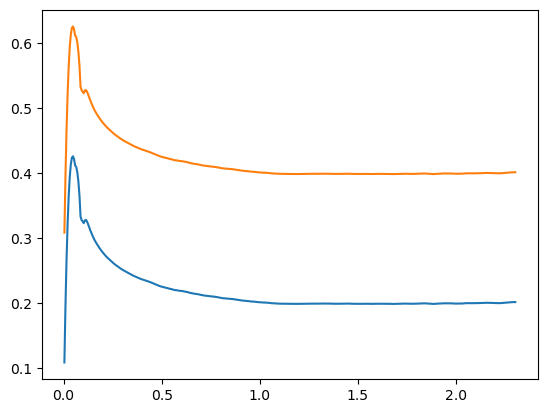

In [22]:
# Plot upper and lower bounds (diagnostic)

plt.plot(all_slice_xs, neutron_lb_fit(all_slice_xs))
plt.plot(all_slice_xs, neutron_ub_fit(all_slice_xs))

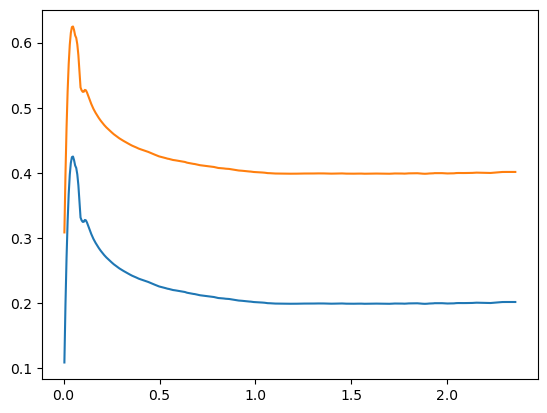

In [23]:
# Plot upper and lower bounds (diagnostic)

plt.plot(all_slice_xs_bg, neutron_lb_fit(all_slice_xs_bg))
plt.plot(all_slice_xs_bg, neutron_ub_fit(all_slice_xs_bg))

In [24]:
%%time
# Classify neutrons under NASA window
psd_report = classify(psd_report, neutron_lb_fit, neutron_ub_fit, "NASA",le_cutoff=L0)

CPU times: user 232 ms, sys: 0 ns, total: 232 ms
Wall time: 233 ms


In [25]:
%%time
# Classify neutrons under NASA window
bg_report = classify(bg_report, neutron_lb_fit_bg, neutron_ub_fit_bg, "NASA",le_cutoff=L0)

CPU times: user 2.71 s, sys: 220 ms, total: 2.93 s
Wall time: 2.94 s


In [26]:
%%time
# Generate random sample of "psd_report" for graphing
# Graphing 300M points is way too slow, so best to graph a reasonable fraction of all points

sample_frac = 0.1  # fraction of points to put in sample (0-1)
random_state = 1323  # random number generator seed; change to try different samples

if sample_frac >= 1:
    graph_sample = psd_report
else:
    graph_sample = psd_report.sample(frac=sample_frac,random_state=random_state)

CPU times: user 59.9 ms, sys: 748 µs, total: 60.6 ms
Wall time: 65.2 ms


In [27]:
%%time
# Generate random sample of "psd_report" for graphing
# Graphing 300M points is way too slow, so best to graph a reasonable fraction of all points

sample_frac = 0.01  # fraction of points to put in sample (0-1)
random_state = 1324  # random number generator seed; change to try different samples

if sample_frac >= 1:
    graph_sample_bg = bg_report
else:
    graph_sample_bg = bg_report.sample(frac=sample_frac,random_state=random_state)

CPU times: user 906 ms, sys: 37 ms, total: 943 ms
Wall time: 946 ms


In [28]:
plot_start = datetime.now()

(<Figure size 1000x1000 with 1 Axes>,
 <AxesSubplot: title={'center': 'Counts = 2235'}, xlabel='Energy (MeVee)', ylabel='PSD'>)

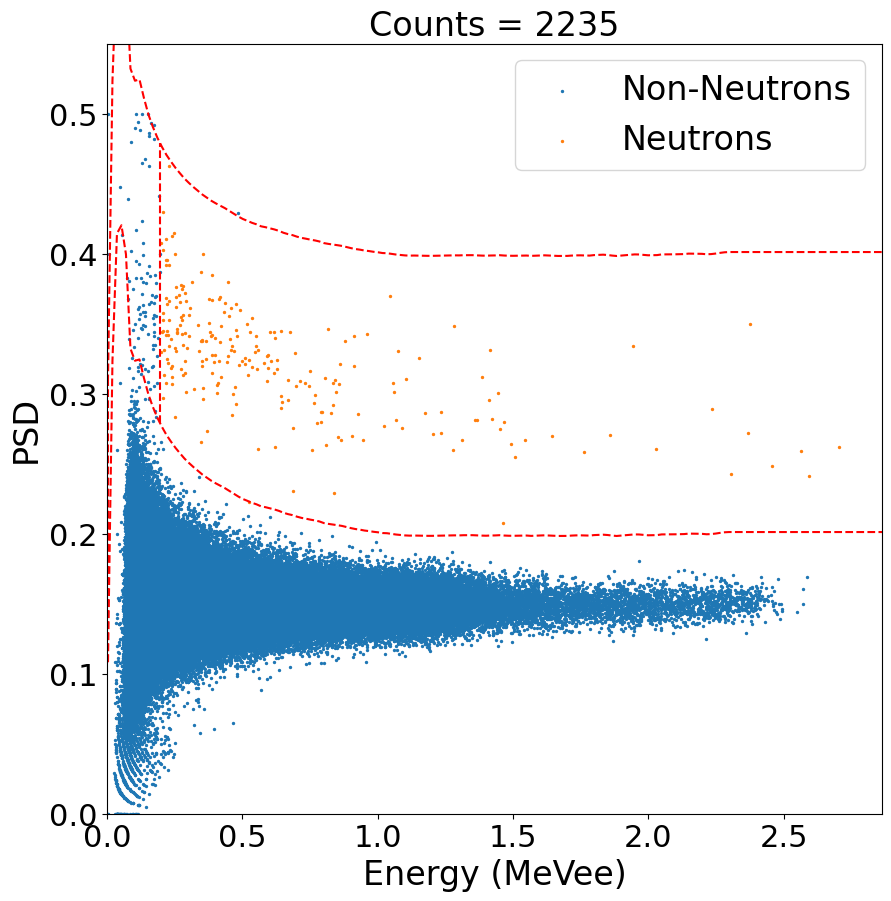

In [29]:
# Plotting NASA classification
plot_classification(
    graph_sample[graph_sample["NASA"]], 
    graph_sample[~graph_sample["NASA"]], 
    neutron_lb_fit, 
    neutron_ub_fit, 
    psd_report["CALIB_ENERGY"].max(), 
    L0,
    psd_report[psd_report["NASA"]].shape[0]
)
# plt.plot(all_slice_xs, df["mu2"])
# plt.plot(all_slice_xs, df["mu1"] + 4 * df["sigma1"])
# plt.xlim(0.2,0.4)
# plt.ylim(0.3, 0.5)

In [30]:
plot_end = datetime.now()
plot_duration = plot_end - plot_start
print(f"Plot execution time: {plot_duration.total_seconds():.3f} s")

Plot execution time: 1.293 s


In [31]:
plot_start = datetime.now()

(<Figure size 1000x1000 with 1 Axes>,
 <AxesSubplot: title={'center': 'Counts = 28274'}, xlabel='Energy (MeVee)', ylabel='PSD'>)

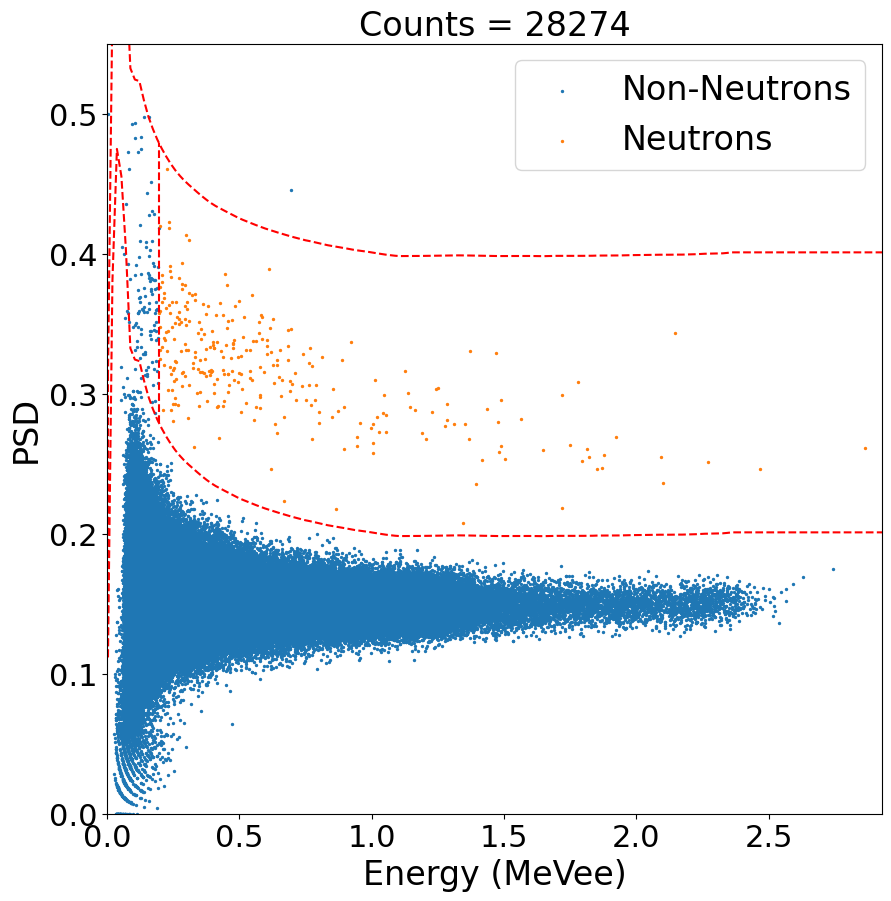

In [32]:
# Plotting NASA classification
plot_classification(
    graph_sample_bg[graph_sample_bg["NASA"]], 
    graph_sample_bg[~graph_sample_bg["NASA"]], 
    neutron_lb_fit_bg, 
    neutron_ub_fit_bg, 
    bg_report["CALIB_ENERGY"].max(), 
    L0,
    bg_report[bg_report["NASA"]].shape[0]
)
# plt.plot(all_slice_xs, df["mu2"])
# plt.plot(all_slice_xs, df["mu1"] + 4 * df["sigma1"])
# plt.xlim(0.2,0.4)
# plt.ylim(0.3, 0.5)

In [33]:
plot_end = datetime.now()
plot_duration = plot_end - plot_start
print(f"Plot execution time: {plot_duration.total_seconds():.3f} s")

Plot execution time: 1.544 s


## Fusion Analysis

### Setting up Trial data structure

In [34]:
# Function definition
# Experiment dataclass definition

def get_sigma_for_count(count: int) -> float:
    """Calculates estimated error for a given event count
    
    Parameters
    ----------
    count: int
        Event count
        
    Returns
    -------
    sigma: float
        Estimated error for the given event count
    """
    return np.sqrt(abs(count))

def get_sigma_for_count_delta(a:int, b:int) -> float:
    """Calculates estimated error for a difference between (or sum of) event counts
    
    Parameters
    ----------
    a, b: int
        Event counts
    
    Returns
    -------
    sigma: float
        Estimated error for the difference between (or sum of) the event counts
    """
    sigma_a = get_sigma_for_count(a)
    sigma_b = get_sigma_for_count(b)
    return np.sqrt(sigma_a**2 + sigma_b**2)

def counts_over_time_histogram(
    timetags: pd.Series, 
    dwell_time: int, 
    start_timetag: int,
    end_timetag: int
) -> tuple[np.ndarray, np.ndarray]:
    """Generates histogram of event counts per dwell time bin over a time period
    
    Parameters
    ----------
    timetags: pd.Series
        timetags (as picoseconds after neutron detector start) for all relevant events 
    dwell_time: int
        time period used for histogram bin width in seconds
    start_timetag: int
        starting timetag (as picoseconds after neutron detector start) for histogram period
    end_timetag: int
        ending timetag (as picoseconds after neutron detector start) for histogram period
    
        
    Returns
    -------
    counts: np.ndarray
        array of counts per bin
    bins: np.ndarray
        bin boundaries (as time in seconds)
    """
#     if total_time % dwell_time == 0:
#         total_time += 0.001
#     input_bins = np.arange(0, total_time, dwell_time)
    dwell_time = dwell_time * 1e12
    if (end_timetag - start_timetag) % dwell_time == 0:
        end_timetag += 1
    input_bins = np.arange(start_timetag, end_timetag, dwell_time)
    counts, bins = np.histogram(timetags, input_bins)
    return counts, bins

@dataclass
class Trial:
    """Class for storing trial data and calculating derived data.
    Each trial has a condition period, during which some experimental
    device was active (i.e. E-cell, plasma, etc.), and a background 
    period, during which the device was not active.
    To ensure correct results, the experimental state should be stable 
    before either period starts. For example, if some experimental parameter
    such as a chemical concentration takes time to increase when the device
    is active, the condition period should only start when that parameter
    reaches a steady value.
    To ensure correct event rate statistics, the condition and background 
    periods should have equal durations.
    
    Parameters
    ----------
    condition_dataframe: pd.DataFrame
        DataFrame containing only events in the condition period
    background_dataframe: pd.DataFrame
        DataFrame containing only events in the background period
    condition_time_bounds: tuple[int, int]
        The timetags that bound the condition period
    background_time_bounds: tuple[int, int]
        The timetags that bound the background period
    """
    condition_dataframe: pd.DataFrame
    background_dataframe: pd.DataFrame
    condition_time_bounds: tuple[int, int]
    background_time_bounds: tuple[int, int]
    
    EPSILON = 1e-6
    
    @property
    def condition_count(self) -> int:
        """The total event count in the condition period"""
        return self.condition_dataframe.shape[0]
    
    @property
    def background_count(self) -> int:
        """The total event count in the background period"""
        return self.background_dataframe.shape[0]
    
    @property
    def condition_time(self) -> float:
        """The total duration of the condition period"""
        start, end = self.condition_time_bounds
        return (end - start) * 1e-12
    
    @property
    def background_time(self) -> float:
        """The total duration of the background period"""
        start, end = self.background_time_bounds
        return (end - start) * 1e-12
    
    def count_delta(self):
        """The difference in total counts between condition and background periods"""
        return self.condition_count - self.background_count

    # Rate methods
    def condition_rate(self):
        """The overall average rate for the condition period"""
        return self.condition_count/self.condition_time
    
    def background_rate(self):
        """The overall average rate for the background period"""
        return self.background_count/self.background_time
    
    def rate_delta(self):
        """The difference in averages rates between condition and background periods"""
        return self.condition_rate() - self.background_rate()
    
    def rate_delta_is_valid(self):
        """Returns True if the condition and background periods have effectively equal durations.
        If this is true, we can consider the calculated rate difference to valid and useful.
        "Effectively equal" means the duration difference is below a small threshold.
        """
        delta_time = abs(self.condition_time - self.background_time)
        return delta_time < self.EPSILON
    
    # Error estimation methods
    def condition_sigma(self):
        """The estimated error in the condition periods' total event count"""
        return get_sigma_for_count(self.condition_count)
    
    def background_sigma(self):
        """The estimated error in the background periods' total event count"""
        return get_sigma_for_count(self.background_count)
    
    def delta_sigma(self):
        """The estimated error in the event count difference"""
        return get_sigma_for_count_delta(self.condition_sigma(), 
                                         self.background_sigma())
    
    def condition_rate_sigma(self):
        """The estimated error in the condition period's average rate"""
        return self.condition_sigma()/self.condition_time
    
    def background_rate_sigma(self):
        """The estimated error in the background period's average rate"""
        return self.background_sigma()/self.background_time
    
    def rate_delta_sigma(self):
        """The estimated error in the average rate difference"""
        return get_sigma_for_count_delta(
            self.condition_rate_sigma(), 
            self.background_rate_sigma())
    
    # Rate histogram methods
    def condition_rate_over_time(
        self, dwell_time: int
    ) -> tuple[np.ndarray, np.ndarray]:
        """Determines the condition period's event rate over time as 
        a histogram.
        
        The condition period is divided into time "bins", and event rates 
        are calculated for each bin.
        
        Parameters
        ----------
        dwell_time: int
            Time bin duration. If the dwell time is such that the final
            bin would be smaller than the dwell time, it is not used.
            Therefore, each time bin always lasts the full dwell time.
            For example, for a period lasting 15 minutes, a dwell time of 
            6 minute would produce only 2 bins of 6 minutes long, with the
            remaining 3 minutes ignored.
            
        Returns
        -------
        rates: np.ndarray
            The event rates for each time bin
        bins: np.ndarray
            The timetag boundaries for each time bin. Since the bins are
            contiguous, and adjacent bins share a boundary, the bins array
            is always one element longer than the rates array.
        """
        return self._rate_over_time(
            dwell_time,
            self.condition_dataframe,
            self.condition_time_bounds
        )
    
    def background_rate_over_time(
        self, dwell_time: int
    ) -> tuple[np.ndarray, np.ndarray]:
        """Determines the background period's event rate over time as 
        a histogram.
        
        The background period is divided into time "bins", and event rates 
        are calculated for each bin.
        
        Parameters
        ----------
        dwell_time: int
            Time bin duration. If the dwell time is such that the final
            bin would be smaller than the dwell time, it is not used.
            Therefore, each time bin always lasts the full dwell time.
            For example, for a period lasting 15 minutes, a dwell time of 
            6 minute would produce only 2 bins of 6 minutes long, with the
            remaining 3 minutes ignored.
            
        Returns
        -------
        rates: np.ndarray
            The event rates for each time bin
        bins: np.ndarray
            The timetag boundaries for each time bin. Since the bins are
            contiguous, and adjacent bins share a boundary, the bins array
            is always one element longer than the rates array.
        """
        return self._rate_over_time(
            dwell_time,
            self.background_dataframe,
            self.background_time_bounds
        )
    
    def condition_rate_histogram(
        self, dwell_time: int, rate_bin_count: int
    ) -> tuple[np.ndarray, np.ndarray]:
        """Determines the condition period's event rate distribution as 
        a histogram.
        
        The event rate histogram is calculated as in the 
        condition_rate_over_time() method. Then, rate bins are produced,
        and the number of rates falling in each bin are counted.
        
        Parameters
        ----------
        dwell_time: int
            Time bin duration for calculating event rates. 
            If the dwell time is such that the final bin would be smaller 
            than the dwell time, it is not used. Therefore, each time bin 
            always lasts the full dwell time. For example, for a period 
            lasting 15 minutes, a dwell time of 6 minute would produce 
            only 2 bins of 6 minutes long, with the remaining 3 minutes 
            ignored.
        rate_bin_count: int
            The number of rate bins to use
            
        Returns
        -------
        counts: np.ndarray
            The count for each event rate bin
        bins: np.ndarray
            The rate boundaries for each event rate bin. Since the bins 
            are contiguous, and adjacent bins share a boundary, the bins 
            array is always one element longer than the rates array.
        """
        rates, _ = self.condition_rate_over_time(dwell_time)
        return np.histogram(rates, rate_bin_count)
    
    def background_rate_histogram(
        self, dwell_time: int, rate_bin_count: int
    ) -> tuple[np.ndarray, np.ndarray]:
        """Determines the background period's event rate distribution as 
        a histogram.
        
        The event rate histogram is calculated as in the 
        condition_rate_over_time() method. Then, rate bins are produced,
        and the number of rates falling in each bin are counted.
        
        Parameters
        ----------
        dwell_time: int
            Time bin duration for calculating event rates. 
            If the dwell time is such that the final bin would be smaller 
            than the dwell time, it is not used. Therefore, each time bin 
            always lasts the full dwell time. For example, for a period 
            lasting 15 minutes, a dwell time of 6 minute would produce 
            only 2 bins of 6 minutes long, with the remaining 3 minutes 
            ignored.
        rate_bin_count: int
            The number of rate bins to use
            
        Returns
        -------
        counts: np.ndarray
            The count for each event rate bin
        bins: np.ndarray
            The rate boundaries for each event rate bin. Since the bins 
            are contiguous, and adjacent bins share a boundary, the bins 
            array is always one element longer than the rates array.
        """
        rates, _ = self.background_rate_over_time(dwell_time)
        return np.histogram(rates, rate_bin_count)
    
    # Stat reporting methods
    def report_count_statistics(self):
        """Prints count statistics for this trial.
        This includes condition and background counts, count difference,
        and estimated error for each.
        """
        print(f"Condition count: {self.condition_count}, Error: {self.condition_sigma():.4f}")
        print(f"Background count: {self.background_count}, Error: {self.background_sigma():.4f}")
        print(f"Count difference: {self.count_delta()}, Error: {self.delta_sigma():.4f}")
    
    def report_rate_statistics(self):
        """Prints rate statistics for this trial.
        This includes condition and background rates, rate difference 
        (with validity), and estimated error for each.
        """
        print(f"Condition rate: {self.condition_rate():.4f}, Error: {self.condition_rate_sigma():.4f}")
        print(f"Background rate: {self.background_rate():.4f}, Error: {self.background_rate_sigma():.4f}")
        print(f"Rate difference: {self.rate_delta():.4f}, Error: {self.rate_delta_sigma():.4f}")
        print(f"Rate difference is{'' if self.rate_delta_is_valid() else ' not'} valid (times = {self.condition_time:.4f}, {self.background_time:.4f})")
    
    # Helpers
    def _rate_over_time(
        self, 
        dwell_time: int, 
        df: pd.DataFrame, 
        bounds: tuple[int, int]
    ) -> tuple[np.ndarray, np.ndarray]:
        counts, bins = counts_over_time_histogram(
            df['TIMETAG'],
            dwell_time,
            *bounds)
        rates = counts/dwell_time
        return rates, bins
        

def report_overall_count_statistics(trials: list[Trial]):
    """Reports overall count statistics for a list of trials."""
    total_cond_count = sum([trial.condition_count for trial in trials])
    total_bg_count = sum([trial.background_count for trial in trials])
    total_delta = total_cond_count - total_bg_count
    
    sigma_cond_count = get_sigma_for_count(total_cond_count)
    sigma_bg_count = get_sigma_for_count(total_bg_count)
    sigma_delta = get_sigma_for_count_delta(total_cond_count, total_bg_count)
    
    print(f"Condition count: {total_cond_count}, Error: {sigma_cond_count:.4f}")
    print(f"Background count: {total_bg_count}, Error: {sigma_bg_count:.4f}")
    print(f"Count difference: {total_delta:.4f}, Error: {sigma_delta:.4f}")

In [35]:
cond_df = psd_report.query('NASA')
bg_df = bg_report.query('NASA')
cond_timetags = (0, psd_report['TIMETAG'].max())
bg_timetags = (0, bg_report['TIMETAG'].max())

trial = Trial(cond_df, bg_df, cond_timetags, bg_timetags)

### Overall Statistics

In [36]:
trial.report_count_statistics()
print()
trial.report_rate_statistics()

Condition count: 2235, Error: 47.2758
Background count: 28274, Error: 168.1487
Count difference: -26039, Error: 14.6773

Condition rate: 0.1402, Error: 0.0030
Background rate: 0.1484, Error: 0.0009
Rate difference: -0.0082, Error: 0.0620
Rate difference is not valid (times = 15946.9721, 190542.2618)


### Count Rate Plot

In [37]:
# Define functions used in count rate plotting
def combine_period_histograms(
    counts: list[np.ndarray], 
    bins: list[np.ndarray]
) -> tuple[np.ndarray, np.ndarray]:
    """Combines period histograms together for proper plotting.
    Since periods are not adjacent, we must properly define the value
    of the intervening time as NaN, so it will not be plotted.
    
    Parameters
    ----------
    counts: list[np.ndarray]
        List of arrays holding bin counts for each period
    bins: list[np.ndarray]
        List of arrays holding bin boundaries for each period.
        Each bin array should be 1 element longer than the corresponding
        count array.
    
    Returns
    -------
    combined_counts: np.ndarray
        Array holding concatenated bin counts over all periods, with
        the time between periods having no count (NaN)
    combined_bins: np.ndarray
        Array holding concatenated bin boundaries over all periods
    """
    combined_bins = np.concatenate(bins, axis=None)
    
    sep = [np.nan] * len(counts)
    separated_counts = list(sum(zip(counts, sep), ())[:-1])
    combined_counts = np.concatenate(separated_counts, axis=None)
    
    return combined_counts, combined_bins


def plot_histogram(
    bins: list[np.ndarray], 
    counts: list[np.ndarray],
    labels: list[str],
    style: Literal['points', 'stairs'] = "points",
    **kwargs
) -> tuple[plt.Figure, plt.Axes]:
    """Plot a set of histograms in one figure
    
    Parameters
    ----------
    bins: list[np.ndarray]
        list of histogram bins to use
    counts: list[np.ndarray]
        list of histogram counts to use
        Each list element must correspond to the element in the same position in `bins`
    labels: list[str]
        list of labels to use
        Each list element must correspond to the element in the same position in `bins`
    style: Literal['points', 'stairs'], default "points"
        plotting style
        The 'points' option creates a scatterplot, while 'stairs' creates a stair plot.
    kwargs
        Other formatting options used in the Matplotlib Axes.plot() or Axes.stairs() functions (as appropriate)
    
    Returns
    -------
    fig: plt.Figure
        plotting container for histogram plot
    ax: plt.Axes
        plot axes for histogram plot
    """
    fig, ax = plt.subplots(dpi=140)
    
    for bin, count, label in zip(bins, counts, labels):
        if style == "points":
            ax.plot(bin[:-1], count, "o", label=label, **kwargs)
        
        elif style == "stairs":
            ax.stairs(count, bin, label=label, lw=4, **kwargs)
    
    ax.legend()
    return fig, ax

In [38]:
# Define dwell time (in seconds)
dwell_time = 60*5

In [39]:
# Get count histogram (and bins) for on/off periods

# ecell_on_results = [trial.condition_rate_over_time(dwell_time) 
#                     for trial in trials]
# ecell_off_results = [trial.background_rate_over_time(dwell_time)
#                      for trial in trials]

# ecell_on_period_cps, ecell_on_period_bins = list(zip(*ecell_on_results))
# ecell_off_period_cps, ecell_off_period_bins = list(zip(*ecell_off_results))

# ecell_on_cps, ecell_on_bins = combine_period_histograms(ecell_on_period_cps, 
#                                                            ecell_on_period_bins)
# ecell_off_cps, ecell_off_bins = combine_period_histograms(ecell_off_period_cps, 
#                                                              ecell_off_period_bins)

cond_cps, cond_bins = trial.condition_rate_over_time(dwell_time)
bg_cps, bg_bins = trial.background_rate_over_time(dwell_time)

Text(0.5, 0, 'Time (s)')

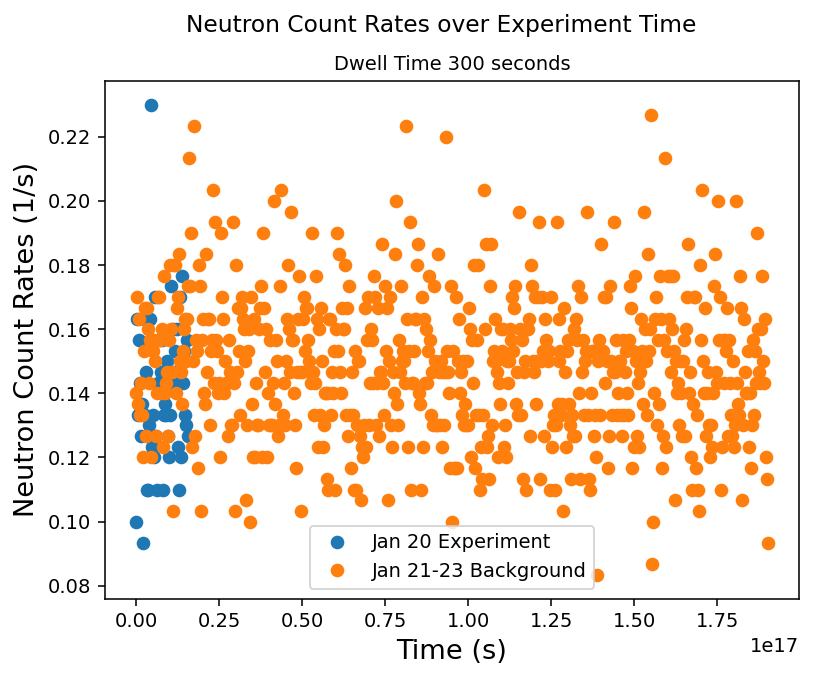

In [40]:
# Plot rates over time, labelled by condition/background

fig, ax = plot_histogram(
    [cond_bins, bg_bins],
    [cond_cps, bg_cps],
    labels=["Jan 20 Experiment", "Jan 21-23 Background"]
)

plt.suptitle("Neutron Count Rates over Experiment Time")
plt.title(f"Dwell Time {dwell_time} seconds", fontsize="medium")
ax.set_ylabel("Neutron Count Rates (1/s)", fontsize=14)
ax.set_xlabel("Time (s)", fontsize=14)

(0.0, 1.5946972077349366e+16)

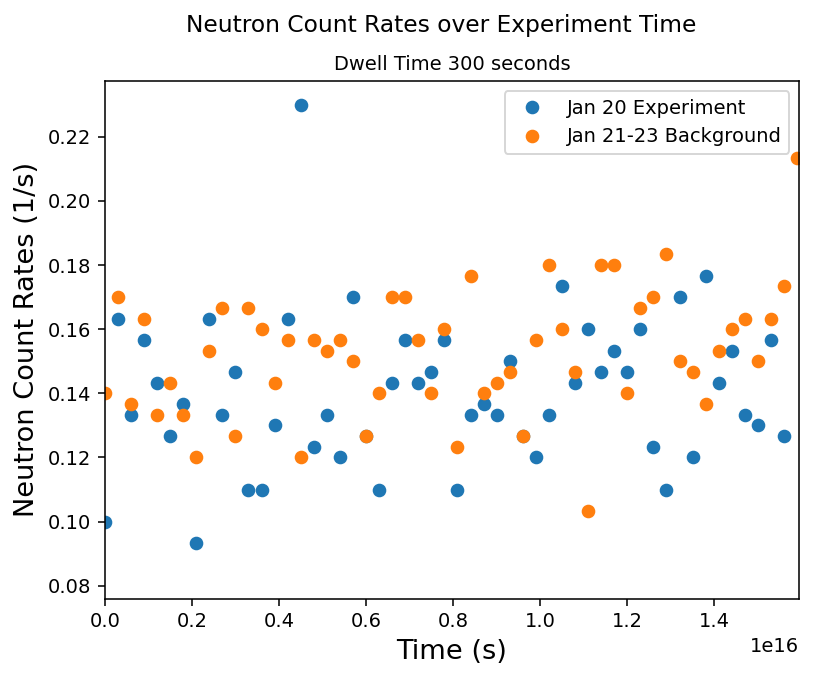

In [41]:
# Plot rates over time, labelled by condition/background

fig, ax = plot_histogram(
    [cond_bins, bg_bins],
    [cond_cps, bg_cps],
    labels=["Jan 20 Experiment", "Jan 21-23 Background"]
)

plt.suptitle("Neutron Count Rates over Experiment Time")
plt.title(f"Dwell Time {dwell_time} seconds", fontsize="medium")
ax.set_ylabel("Neutron Count Rates (1/s)", fontsize=14)
ax.set_xlabel("Time (s)", fontsize=14)
ax.set_xlim(cond_timetags)

### Trial CPS Histograms

Experimental counts: 20 elements
 [ 3  4 18  0 23 29  0 32 32  0 37 20 20  0 15 19  0  5  5  3]
Bin bounds: 21 elements
 [0.03333333 0.045      0.05666667 0.06833333 0.08       0.09166667
 0.10333333 0.115      0.12666667 0.13833333 0.15       0.16166667
 0.17333333 0.185      0.19666667 0.20833333 0.22       0.23166667
 0.24333333 0.255      0.26666667]
Bin widths: 20 elements
[0.01166667 0.01166667 0.01166667 0.01166667 0.01166667 0.01166667
 0.01166667 0.01166667 0.01166667 0.01166667 0.01166667 0.01166667
 0.01166667 0.01166667 0.01166667 0.01166667 0.01166667 0.01166667
 0.01166667 0.01166667]
Lower bounds: 20 elements
[0.03333333 0.045      0.05666667 0.06833333 0.08       0.09166667
 0.10333333 0.115      0.12666667 0.13833333 0.15       0.16166667
 0.17333333 0.185      0.19666667 0.20833333 0.22       0.23166667
 0.24333333 0.255     ]
Rates (bin midpoints): [0.03916667 0.05083333 0.0625     0.07416667 0.08583333 0.0975
 0.10916667 0.12083333 0.1325     0.14416667 0.15583333 0

Text(0.5, 0.98, 'Neutron Count Rate Distributions\nDwell Time 60 seconds, 20 Rate Bins')

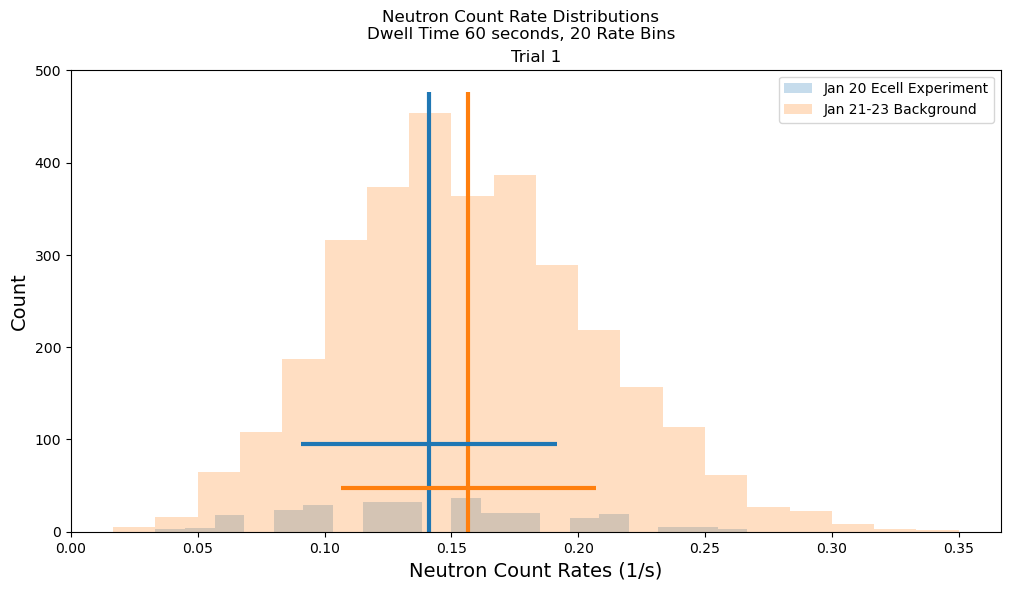

In [54]:
# Plot CPS histogram for each trial
trials = [trial]

dwell_time = 60*1
ideal_columns = 4
cps_n_bins = 20

exp_count = len(trials)
columns = min(exp_count, ideal_columns)
rows = -(-exp_count // ideal_columns)

fig, axs = plt.subplots(rows, columns, squeeze=False, figsize=(12, 6))
axs_flattened = [ax for row in axs for ax in row]

for i, (ax, trial) in enumerate(list(zip(axs_flattened, trials))):
    cond_counts, cond_bin_bounds = trial.condition_rate_histogram(dwell_time,
                                                            cps_n_bins)
    bg_counts, bg_bin_bounds = trial.background_rate_histogram(dwell_time,
                                                         cps_n_bins)
    cps_results = ((cond_counts, cond_bin_bounds),
                   (bg_counts, bg_bin_bounds))
    
    cond_rates, _ = trial.condition_rate_over_time(dwell_time)
    bg_rates, _ = trial.background_rate_over_time(dwell_time)
    alt_cond_sigma = np.std(cond_rates)
    alt_bg_sigma = np.std(bg_rates)
    
    print(f"Experimental counts: {len(cond_counts)} elements\n {cond_counts}")
    print(f"Bin bounds: {len(cond_bin_bounds)} elements\n {cond_bin_bounds}")
    
    # Calculating mean rate and estimated error

    cond_bin_widths = np.diff(cond_bin_bounds)
    bin_widths = tuple((np.diff(bin_bounds) for _, bin_bounds in cps_results))
    cond_bin_lbs = cond_bin_bounds[:-1]
    
    print(f"Bin widths: {len(cond_bin_widths)} elements\n{cond_bin_widths}")
    print(f"Lower bounds: {len(cond_bin_lbs)} elements\n{cond_bin_lbs}")
    
    cond_bin_rates = cond_bin_widths/2 + cond_bin_lbs
    bg_bin_rates = np.diff(bg_bin_bounds)/2 + bg_bin_bounds[:-1]
    print(f"Rates (bin midpoints): {cond_bin_midpoints}")
    
    # Avg = SUM_I(count_i*rate_i)/SUM_I(count_i)
    total_cond_count = np.sum(cond_counts, axis=None)
    cond_weighted_rates = cond_counts*cond_bin_rates
    cond_total_weighted_rate = np.sum(cond_weighted_rates, axis=None)
    print(f"Total count: {total_cond_count}")
    print(f"Weighted rate: {cond_weighted_rates}")
    print(f"Total weighted rate: {cond_total_weighted_rate}")
    
    mean_cond_rate = cond_total_weighted_rate / total_cond_count
    mean_bg_rate = np.sum(
        bg_counts*bg_bin_rates, axis=None
    )/np.sum(
        bg_counts, axis=None
    )
    print(f"Mean rate: {mean_cond_rate}")
    
    # Sigma = sqrt(SUM_I[(rate_i-avg)^2*count_i])
    cond_rate_deviances = cond_bin_midpoints-mean_cond_rate
    cond_sq_rate_deviances = cond_rate_deviances**2
    cond_weighted_deviances = cond_sq_rate_deviances * cond_counts
    cond_total_weighted_deviance = np.sum(cond_weighted_deviances)
    print(f"Rate deviances: {cond_rate_deviances}")
    print(f"Squared rate deviances: {cond_sq_rate_deviances}")
    print(f"Weighted deviances: {cond_weighted_deviances}")
    print(f"Total deviance: {cond_total_weighted_deviance}")
    
    sigma_cond_rate = np.sqrt(cond_total_weighted_deviance)
    sigma_bg_rate = np.sqrt(
        np.sum(
            (bg_bin_midpoints-mean_bg_rate)**2 * bg_counts
        )
    )
    print(f"Sigma: {sigma_cond_rate}")
    
    print(f"Trial {i+1}:")
    print(f"Weighted mean condition rate: {mean_cond_rate:.4f}, Error: {sigma_cond_rate:.4f}")
    print(f"Weighted mean background rate: {mean_bg_rate:.4f}, Error: {sigma_bg_rate:.4f}")
    print(f"Alternate condition SD: {alt_cond_sigma:.4f}")
    print(f"Alternate background SD: {alt_bg_sigma:.4f}")

    stairs_format = dict(lw=2, alpha=0.25, fill=True)
    ax.stairs(cond_counts, cond_bins, label="Jan 20 Ecell Experiment", **stairs_format)
    ax.stairs(bg_counts, bg_bins, label="Jan 21-23 Background", **stairs_format)
    
    ylim_lo, ylim_hi = ax.get_ylim()
    best_x_lim = ax.get_xlim()
    bg_sigma_y = 0.1 * (ylim_hi - ylim_lo) + ylim_lo
    cond_sigma_y = 0.2 * (ylim_hi - ylim_lo) + ylim_lo
    
    lines_format = dict(colors=["C0", "C1"], linestyles='solid', linewidth=3)
    ax.vlines([mean_cond_rate, mean_bg_rate], 
              ylim_lo, ylim_hi, 
              **lines_format)
    ax.hlines([cond_sigma_y, bg_sigma_y],
#               [mean_cond_rate - sigma_cond_rate, 
#                mean_bg_rate - sigma_bg_rate],
#               [mean_cond_rate + sigma_cond_rate, 
#                mean_bg_rate + sigma_bg_rate],
              [mean_cond_rate - alt_cond_sigma,
               mean_bg_rate - alt_bg_sigma],
              [mean_cond_rate + alt_cond_sigma,
               mean_bg_rate + alt_bg_sigma],
              **lines_format)
#     ax.set_xlim(*best_x_lim)  # Fix x limits when sigma is too big
    
    ax.set_xlabel("Neutron Count Rates (1/s)", fontsize=14)
    ax.set_ylabel("Count", fontsize=14)
    ax.set_title(f"Trial {i+1}")
    ax.legend()
    
plt.suptitle(f"Neutron Count Rate Distributions\nDwell Time {dwell_time} seconds, {cps_n_bins} Rate Bins")

In [43]:
end_dt = datetime.now()
elapsed = end_dt - start_dt
print(f"Total run time: {elapsed.total_seconds():.3f} s")

Total run time: 52.111 s
